# Iris dimensionality reduction

### General

As an example of an unsupervised learning problem, take a look at reducing the dimensionality of the Iris data so as to more easily visualize it. Recall that the Iris data is four dimensional: there are four features recorded for each sample.

The task of dimensionality reduction is to ask whether there is a suitable lower-dimensional representation that retains the essential features of the data. Often dimensionality reduction is used as an aid to visualizing data; after all, it is much easier to plot data in two dimensions than in four dimensions or higher!

### Coding tasks

Below you can find some code snippets, that has parts already done - do not touch them. They are needed to successfully complete this assignment. In the coding blocks you find a comment starting
`TODO:`. You should fill the requested parts from the code.

## Import libraries and load data
- The first step should always be to import all libraries and load data
- Also examining the data is important

In [76]:
# Import all libraries needed
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt

# load data
iris = sns.load_dataset('iris') 
print(iris.head()); print()
print(iris.describe()); print()

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000



## Feature Matrix and Target Array
- Feature Matrix means those variables, that are used in PCA. 
- Target Array means the classification information.

- In the example of Iris dataset, the classification would be 3 different flower species
- While the Features could be any predictor variables, such as:
  - sepal_length, sepal_width, petal_length, petal_width

In [77]:
# TODO:
# create y_iris target array
y = iris["species"]

# create X_iris feature matrix
X = iris.drop(columns=["species"])

print(y.head()); print()
print(X.head()); print()


0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2



## Scale the data

- It is important to scale the data for most kind of machine learning models. 
- We can use the sklearn library's StandardScaler()

In [78]:
scaler = StandardScaler()
scaled_X = pd.DataFrame(scaler.fit_transform(X))
scaled_X.head()

,0,1,2,3
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


## Principal Component Analysis
Use principal component analysis (PCA), which is a fast linear dimensionality reduction technique, to reduce the dimensions to two (x and y). PCA can be found from sklearn-decomposition package (see the code). Ask the model to return two components — that is, a two-dimensional representation of the data.

Please note that PCA components combine attributes of multiple predictor variables.

In [80]:
# Choose the model class PCA
from sklearn.decomposition import PCA 

# TODO:
# Fit and transform the data to two dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_X)
pca_variables = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
print(pca_variables.head())




        PC1       PC2
0 -2.264703  0.480027
1 -2.080961 -0.674134
2 -2.364229 -0.341908
3 -2.299384 -0.597395
4 -2.389842  0.646835


Finally plot the results. A quick way to do this is to insert the results into the original Iris DataFrame, and use Seaborn’s lmplot to show the results. For more info about lmplot see https://seaborn.pydata.org/tutorial/regression.html

> Hint! To better separate the individual items, one can use hue input-parameter!

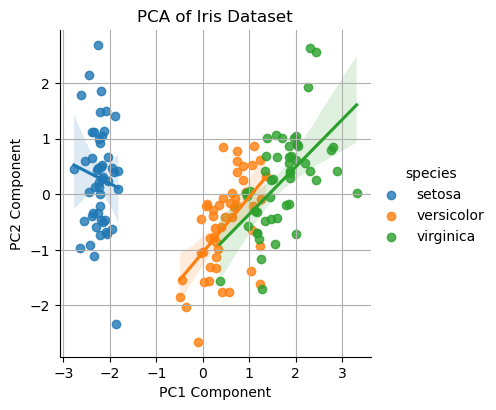

In [89]:
# TODO:
# Plot the results using lmplot

# first add the pca components to original dataframe
# parameter axis means we concatenate columns (0 would be rows)
iris2 = pd.concat([iris, pca_variables], axis=1)
#print(iris2.head()); print()
#print(iris2["PC1"][100:103]); print()
#print(iris2["PC2"][100:103]); print()

# next visualize using seaborn's lmplot library
# make different species separate color with hue parameter
sns.lmplot(data=iris2, x="PC1", y="PC2", hue="species", height=4)

plt.xlabel('PC1 Component')
plt.ylabel('PC2 Component')
plt.title('PCA of Iris Dataset')
plt.grid()
plt.show()




## Conclusions

TODO: Describe shortly with reasoning, what kind of conclusions you find from the plot.

- The first observation is that, PC1 component predicts very clearly, whether the species is setosa or other
- If PC1 is under -1.5, it is ~100% setosa

- The other 2 species are more hard to classify based on PCA components.
- PC1 seems to predict quite well also whether species is versicolor or virginica.
- If -1 > PC1 > 0.8, it is like 95% versicolor.
- If  1.4 > PC1 > 4, it is 95% virginica.

- The area between 0.8 > PC1 > 1.4 is the most difficult one. There is a lot of overlapping values.
- If -3 > PC2 > -1.75, then it is most likely versicolor
- if 1 > PC2 > 3, then it is most likely virginica

- But we cannot totally separate versicolor and virginica based on our PCA component analysis